## American options pricing
In this notebook, we will present different methods for pricing american options.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

In [90]:
class AmericanOptions:
    def __init__(self, r, sigma):
        self.sigma = sigma
        self.r = r

    def __call__(self, T, n, S0):
        dt = T / n  # Time step
        Z = np.random.normal(0, 1, n)  # Brownian motion increments
        S = [S0]  # Store stock prices
        
        for i in range(n):  # Iterate n times
            S_next = S[-1] * np.exp((self.r - 0.5 * self.sigma**2) * dt + self.sigma * np.sqrt(dt) * Z[i])
            S.append(S_next)
        
        return np.array(S)  # Convert list to numpy array



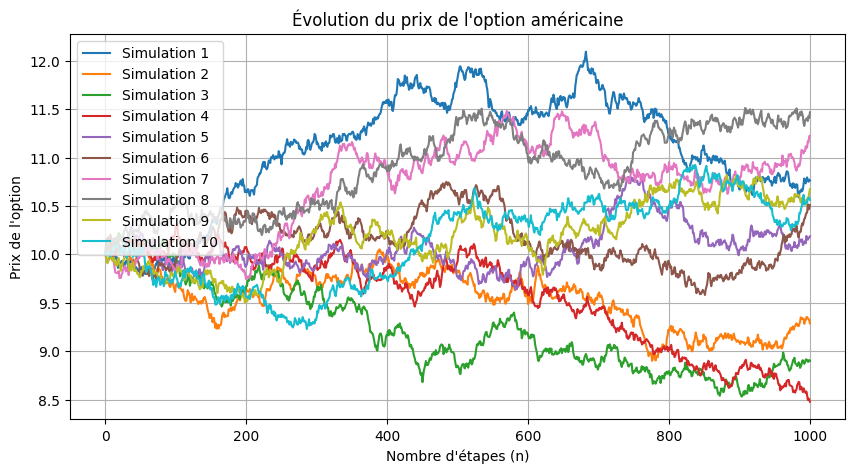

In [91]:
import matplotlib.pyplot as plt

N = 10
n = 1000

plt.figure(figsize=(10, 5))

for _ in range(N):
    option = AmericanOptions(r=0.05, sigma=0.1)
    prices = option(T=1, n=n, S0=10)
    plt.plot(range(n + 1), prices, label=f"Simulation {_ + 1}")

# Ajout de titres et labels
plt.title("Évolution du prix de l'option américaine")
plt.xlabel("Nombre d'étapes (n)")
plt.ylabel("Prix de l'option")
plt.legend()
plt.grid(True)

plt.show()


In [92]:
def payoff(S,K) :
    return np.maximum(K-S,0)

In [93]:
N = 1000
n = 1000
S0 = 11
r = 0.05
sigma = 0.1
T = 1

simulations = []  # Fixed the typo in "siumlations"

for _ in range(N):
    option = AmericanOptions(r=r, sigma=sigma)
    prices = option(T=T, n=n, S0=S0)
    simulations.append(prices)

# Convert the list to a NumPy array
S= np.array(simulations)

print(S.shape)  # This will print (1000, ?) depending on prices shape


(1000, 1001)


In [94]:
V = np.zeros((N,n+1))
K = S0
V[:, -1] = payoff(S[:, -1], K)


1000
1000


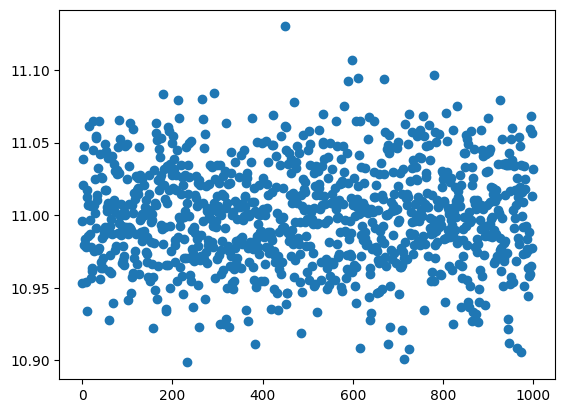

In [95]:
S1 = S[:,1]
len(S1)
print(len(S1))
print(n)
plt.scatter(range(0,N),S1)
plt.show()

In [96]:
dt = T/n
# Backward Induction
for i in range(n-1, 0, -1):  # Iterate backwards from the second last time step
    S_i = S[:, i]
    V_i_1 = V[:, i+1]
    V_i = np.exp(-r * dt) * V_i_1  # Discounted future value
    
    # Fit continuation value using Laguerre polynomials
    fit = np.polynomial.Laguerre.fit(S_i, V_i, deg=15)  # Choose degree 3
    # Compute continuation value
    continuation_value = fit(S_i)

    # Immediate exercise value
    exercise_value = payoff(S_i, K)

    # Apply early exercise condition
    V[:, i] = np.where(exercise_value > continuation_value, exercise_value, V_i)

# Compute option price (discounted expectation)
option_price = np.exp(-r * dt) * np.mean(V[:, 1])

print(f"American Option Price: {option_price:.4f}")


/home/hassene/.local/lib/python3.10/site-packages/numpy/polynomial/laguerre.py:1401: RankWarning: The fit may be poorly conditioned
  return pu._fit(lagvander, x, y, deg, rcond, full, w)


American Option Price: 0.2879


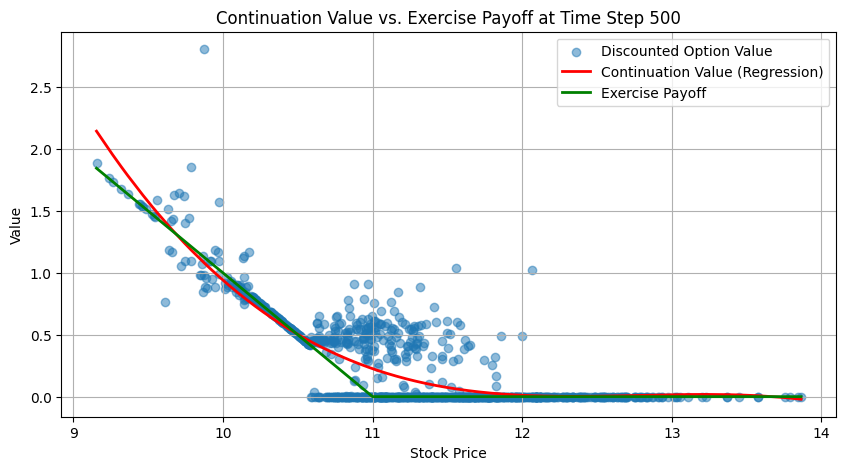

In [97]:
i = n // 2  # Pick a mid-time step
S_i = S[:, i]
V_i = V[:, i]
fit = np.polynomial.Laguerre.fit(S_i, V_i, deg=3)  # Regression fit
continuation_value = fit(S_i)
exercise_value = payoff(S_i, K)

plt.figure(figsize=(10, 5))
plt.scatter(S_i, V_i, label="Discounted Option Value", alpha=0.5)
plt.plot(np.sort(S_i), fit(np.sort(S_i)), label="Continuation Value (Regression)", color="red", linewidth=2)
plt.plot(np.sort(S_i), payoff(np.sort(S_i), K), label="Exercise Payoff", color="green", linewidth=2)
plt.xlabel("Stock Price")
plt.ylabel("Value")
plt.title(f"Continuation Value vs. Exercise Payoff at Time Step {i}")
plt.legend()
plt.grid()
plt.show()


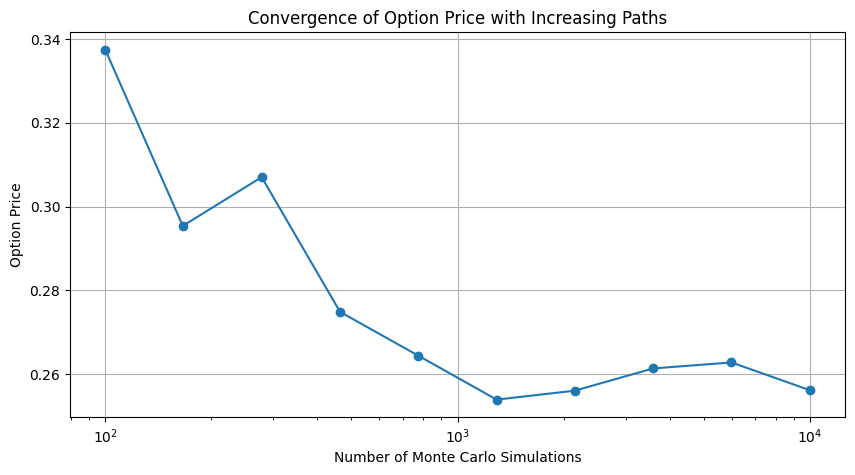

In [98]:
num_paths = np.logspace(2, 4, 10, dtype=int)  # Vary number of paths
option_prices = []

for N_test in num_paths:
    S_test = np.zeros((N_test, n+1))
    S_test[:, 0] = S0
    for i in range(1, n+1):
        Z = np.random.normal(size=N_test)
        S_test[:, i] = S_test[:, i-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    V_test = np.zeros_like(S_test)
    V_test[:, -1] = payoff(S_test[:, -1], K)

    for i in range(n-1, 0, -1):
        S_i = S_test[:, i]
        V_i = np.exp(-r * dt) * V_test[:, i+1]
        fit = np.polynomial.Laguerre.fit(S_i, V_i, deg=3)
        continuation_value = fit(S_i)
        V_test[:, i] = np.where(payoff(S_i, K) > continuation_value, payoff(S_i, K), V_i)

    option_price = np.exp(-r * dt) * np.mean(V_test[:, 1])
    option_prices.append(option_price)

plt.figure(figsize=(10, 5))
plt.plot(num_paths, option_prices, marker='o', linestyle='-')
plt.xscale("log")
plt.xlabel("Number of Monte Carlo Simulations")
plt.ylabel("Option Price")
plt.title("Convergence of Option Price with Increasing Paths")
plt.grid()
plt.show()


Prix du call down-and-out : 8.246741703123966


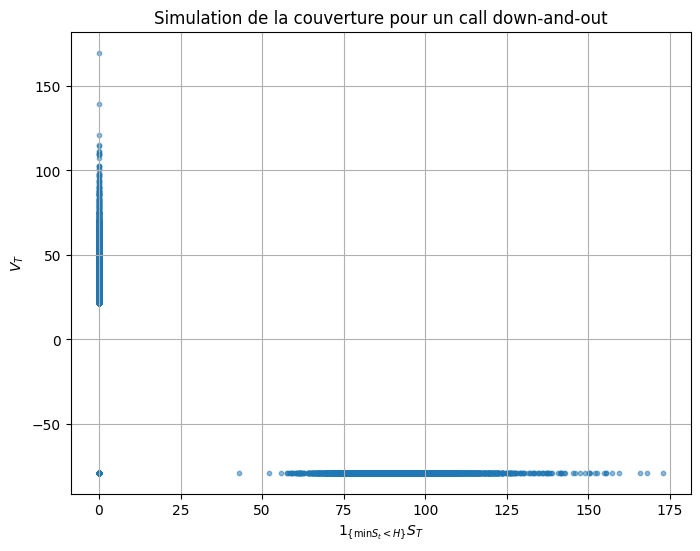

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Paramètres de l'option et du marché
S0 = 100       # Prix initial du sous-jacent
H = 90         # Barrière (H < S0)
K = 100        # Strike
r = 0.05       # Taux d'intérêt sans risque
sigma = 0.2    # Volatilité
T = 1.0        # Maturité (en années)
N = 252        # Nombre de pas de temps (daily)
dt = T / N

# Nombre de trajectoires pour la simulation Monte Carlo
M = 1000

# --- Partie 1 : Calcul du prix par formule explicite ---

def down_and_out_call_price(S, K, H, r, sigma, T):
    # Paramètre lambda
    lam = r / sigma**2 - 0.5
    # d1 et d2 pour le call européen standard
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    # d1* et d2* pour le terme de barrière
    eta = np.log(S / H) / (sigma * np.sqrt(T))
    d1_star = d1 - 2 * eta
    d2_star = d2 - 2 * eta

    price = S * (norm.cdf(d1) - (H / S)**(2 * lam) * norm.cdf(d1_star)) - \
            K * np.exp(-r * T) * (norm.cdf(d2) - (H / S)**(2 * lam - 2) * norm.cdf(d2_star))
    return price

# Calcul du prix initial du call down-and-out
price_DO = down_and_out_call_price(S0, K, H, r, sigma, T)
print("Prix du call down-and-out :", price_DO)

# --- Partie 2 : Simulation de la couverture par delta-hedging ---

# Pour simplifier, nous utiliserons une approximation numérique du delta par différences finies
def option_price_down_and_out(S, K, H, r, sigma, T):
    # On suppose que T reste constant ici et on applique la formule explicite
    return down_and_out_call_price(S, K, H, r, sigma, T)

def option_delta(S, K, H, r, sigma, T, eps=1e-4):
    # Delta approximé par différence finie
    price_up = option_price_down_and_out(S + eps, K, H, r, sigma, T)
    price_down = option_price_down_and_out(S - eps, K, H, r, sigma, T)
    return (price_up - price_down) / (2 * eps)

# Simulation des trajectoires et de la couverture
# Initialisations
S_paths = np.zeros((M, N+1))
S_paths[:, 0] = S0

# Pour stocker la valeur du portefeuille
V = np.zeros((M, N+1))
# Au départ, on finance la position par le prix de l'option
V[:, 0] = price_DO

# On stocke le delta courant
delta = np.zeros((M, N+1))

# On va rebalancer chaque pas de temps
for i in range(M):
    # Pour chaque trajectoire, initialisation
    S = S0
    V_port = price_DO
    # Calcul initial du delta
    delta_curr = option_delta(S, K, H, r, sigma, T)
    delta[i, 0] = delta_curr
    B = V_port - delta_curr * S  # position en numéraire
    for j in range(1, N+1):
        # Mise à jour du temps restant
        t = j * dt
        T_remaining = T - t
        # Simulation de l'évolution du sous-jacent
        Z = np.random.normal()
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
        S_paths[i, j] = S
        
        # Mise à jour de la position en numéraire (croissance à taux r)
        B = B * np.exp(r * dt)
        
        # Si la barrière a déjà été franchie, l'option est knockout
        # Nous pouvons identifier cette situation en vérifiant si le minimum atteint jusqu'ici est < H.
        if np.min(S_paths[i, :j+1]) < H:
            # Une fois knockout, le delta devient nul
            delta_curr = 0
        else:
            # Recalcul du delta pour le temps restant T_remaining
            # Pour éviter des problèmes quand T_remaining est proche de 0, on utilise max(T_remaining, petit epsilon)
            T_eff = max(T_remaining, 1e-8)
            delta_curr = option_delta(S, K, H, r, sigma, T_eff)
        
        delta[i, j] = delta_curr
        
        # Rebalancement : la valeur du portefeuille est la somme de la position en actions et en numéraire
        V_port = delta_curr * S + B
        V[i, j] = V_port

# La valeur finale du portefeuille
V_T = V[:, -1]
S_T = S_paths[:, -1]
# Pour chaque trajectoire, l'indicateur de barrière est 1 si la barrière a été franchie
indicator = (np.min(S_paths, axis=1) < H).astype(int)
# On représente (indicator * S_T, V_T)
x_values = indicator * S_T

plt.figure(figsize=(8,6))
plt.scatter(x_values, V_T, alpha=0.5, s=10)
plt.xlabel(r"$1_{\{\min S_t < H\}}S_T$")
plt.ylabel(r"$V_T$")
plt.title("Simulation de la couverture pour un call down-and-out")
plt.grid(True)
plt.show()
